In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
from scipy import stats
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm


from scipy.stats import linregress

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable


from pylab import rcParams
rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

## Fig2 a-c

In [3]:
fig2a = xr.open_dataset('../preprocessed_data/fig2a.nc')
d_2023 = xr.Dataset({'sst': fig2a['d_2023']})
d_composite = xr.Dataset({'sst': fig2a['d_composite']})
w2023 = xr.Dataset({'w': fig2a['w2023']})
wcomposite = xr.Dataset({'w': fig2a['wcomposite']})
ocean_mask = fig2a['ocean_mask']


In [5]:
comparision = d_2023.sst>d_composite.sst
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5


#difference between 2023 and composite
diff = d_2023-d_composite.mean('year')


/tmp/ipykernel_1472367/747846195.py:100: UserWarning: linewidths is ignored by contourf
  ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,


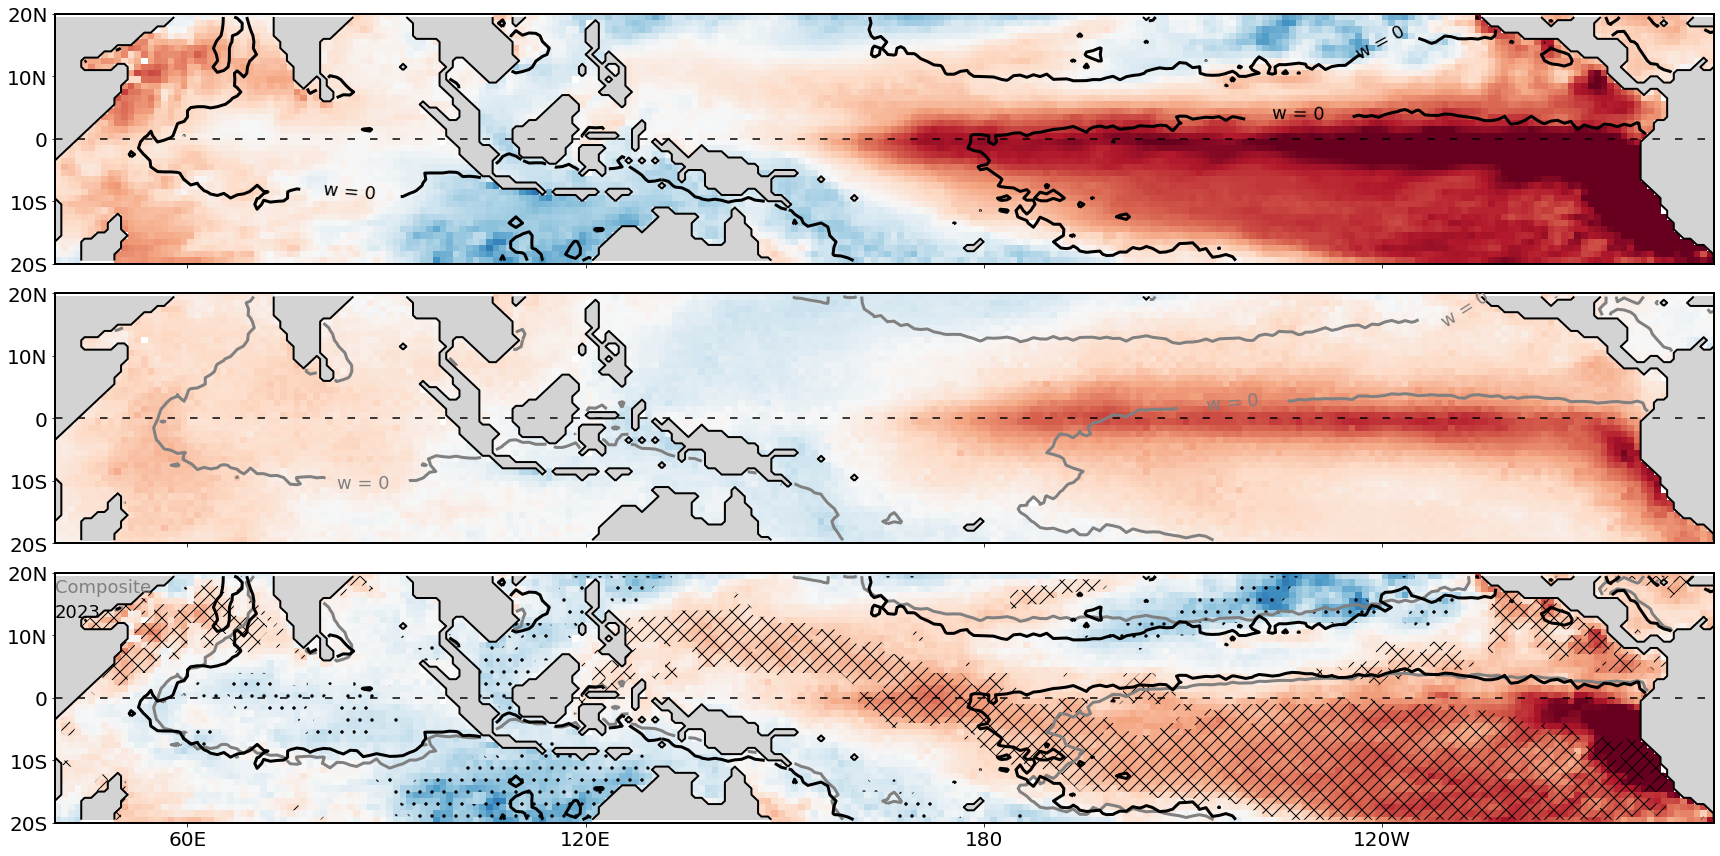

In [6]:
fig, axes = plt.subplots(3,1, figsize = (24,12), sharex = True)


cbar = d_2023.sst.plot(cmap = 'RdBu_r', vmin = -2, vmax = 2, ax = axes[0], add_colorbar = False)

# Plot the contour
CS1 = w2023.w.plot.contour(levels=[-0.0], ax=axes[0], colors = 'k', linewidths = 3)
axes[0].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
axes[0].set_title('')

#-----------------------------


cbar = d_composite.mean('year').sst.plot(cmap = 'RdBu_r', vmin = -2, vmax = 2,add_colorbar = False, ax = axes[1])

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[1], colors = 'grey', linewidths = 3)
axes[1].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
axes[1].set_title('')

#---------------------
cbar = diff.sst.plot(cmap = 'RdBu_r', vmin = -2, vmax = 2, add_colorbar = False)#label=r'$\Delta SST [K]$')

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[2], colors = 'grey', linewidths = 3)
CS2 = w2023.w.plot.contour(levels=[-0.0], ax=axes[2], colors = 'k', linewidths = 3)
#axes[2].clabel(CS1, CS1.levels, inline=True, fmt={0:'composite'}, fontsize=12);
#axes[2].clabel(CS2, CS2.levels, inline=True, fmt={0:'2023'}, fontsize=12);
axes[2].set_title('')

#------------------significance masking psotive
comparision = d_2023.sst>d_composite.sst
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5

# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)
plt.contourf(
    diff.lon, diff.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


"""# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_at_least_four,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)"""


#------------------significance masking negatie
comparision = d_2023.sst<d_composite.sst
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5

# Add diagonal hatching for significant regions
plt.contourf(
    diff.lon, diff.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['.'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)

for ax in axes: 
    #ax.set_xlim(40, 290)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks(ax.get_yticks()[::2])
    
    xtick_position = [60, 120, 180, 240] 
    xtick_labels = [ '60E', '120E', '180', '120W']
    ax.set_xticks(ticks = xtick_position,)
    ax.set_xticklabels(xtick_labels, fontsize = 20)
    ax.set_yticklabels(['20S', '10S', '0', '10N', '20N'], fontsize=20)
    
    #ax.spines[:].set_visible(False)
    ax.spines[:].set_linewidth(2)

#contours for ocean
for ax in axes:  
    ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
               levels=[0.5], colors='black', linewidths=2)
    ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,
                   levels=[0,0.5], colors='lightgrey', linewidths=2)


    
    
# Manually add a text box with "Composite" in grey and "2023" in black
axes[2].text(40, 17, "Composite", color="grey", fontsize=18, fontweight="normal")
axes[2].text(40, 13, "2023", color="black", fontsize=18, fontweight="normal")

#equator lines

for ax in axes:
    ax.axhline(0, linestyle=(0, (5, 10)), c = 'k')
    ax.set_xlim(40, 290)



plt.tight_layout()

## Fig 2 d-f

In [15]:

fig2d = xr.open_dataset('../preprocessed_data/fig2d.nc')

delta_n23 = xr.Dataset({'n': fig2d['delta_n23']})
delta_ncomposite = xr.Dataset({'n': fig2d['delta_ncomposite']})
diff_AS = xr.Dataset({'n': fig2d['diff_AS']})
w2023 = xr.Dataset({'w': fig2d['w_2023']})
wcomposite = xr.Dataset({'w': fig2d['w_composite']})
ocean_mask = fig2d['ocean_mask']





delta_ndiff = delta_n23 - delta_ncomposite

change = delta_ndiff.n
a = delta_n23.n
b = diff_AS.n

/home/jmex/.conda/envs/myenv-3.9/lib/python3.9/site-packages/xarray/plot/plot.py:1415: UserWarning: The following kwargs were not used by contour: 'label'
  primitive = ax.contour(x, y, z, **kwargs)
/tmp/ipykernel_1551417/120957162.py:152: UserWarning: linewidths is ignored by contourf
  ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,


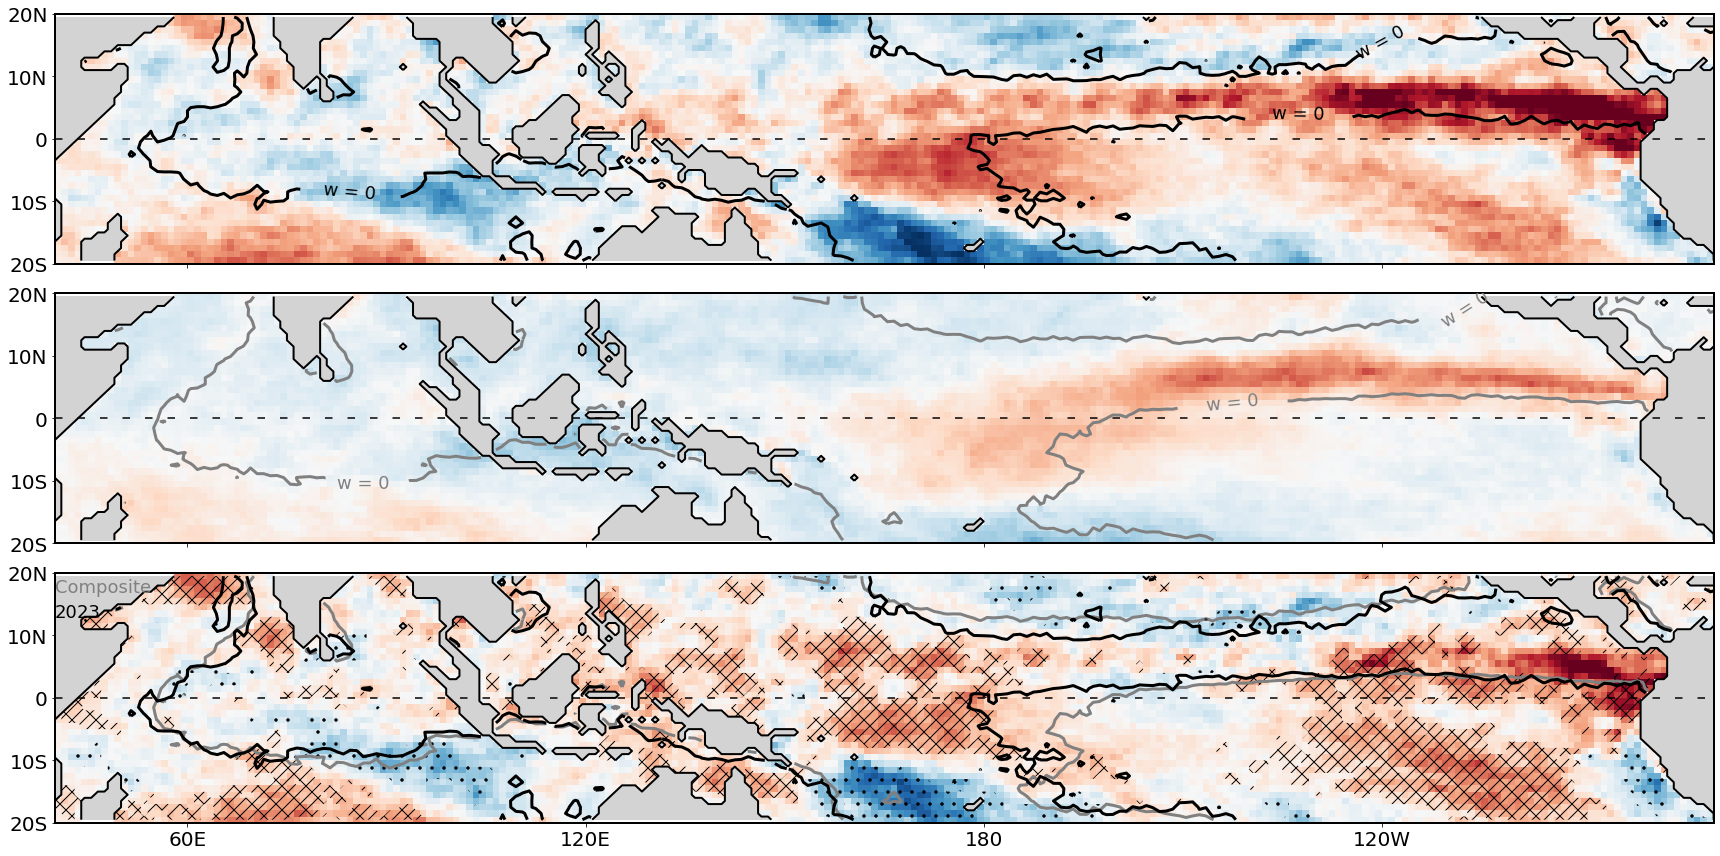

In [16]:
fig, axes = plt.subplots(3,1, figsize = (24,12), sharex = True)


# Define boundaries for discrete levels
bounds = np.linspace(-20,20 , 11)  # 10 discrete intervals between -20 and 20
norm = BoundaryNorm(boundaries=bounds, ncolors=18)

norm = mcolors.Normalize(vmin = -20, vmax = 20)

# Apply the colormap with the BoundaryNorm
cbar = delta_n23.n.plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=axes[0], 
    add_colorbar=False
)
#plt.colorbar(cbar, ax = axes[0], label = 'N Change [W/m2]')


axes[0].set_ylabel('Latitude')
axes[0].set_xlabel('')


# Plot the contour
CS1 = w2023.w.plot.contour(levels=[-0.0], ax=axes[0], colors= 'k', linewidths = 3)
axes[0].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)
axes[0].set_title('')


#-----------------------------
# Apply the colormap with the BoundaryNorm
cbar = delta_ncomposite.n.plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=axes[1], 
    add_colorbar=False
)
#plt.colorbar(cbar, ax = axes[1], label = 'N Change [W/m2]')

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[1], colors = 'grey', linewidths = 3)
axes[1].clabel(CS1, CS1.levels, inline=True, fmt={0:'w = 0'}, fontsize=18)


axes[1].set_ylabel('Latitude')
axes[1].set_xlabel('')
axes[1].set_title('')



#-----------------------------
# Apply the colormap with the BoundaryNorm
cbar = delta_ndiff.n.plot(
    cmap='RdBu_r', 
    norm=norm, 
    ax=axes[2], 
    add_colorbar=False
)

# Plot the contour
CS1 = wcomposite.w.plot.contour(levels=[-0.0], ax=axes[2], label = 'composite', colors = 'grey', linewidths = 3)
CS2 = w2023.w.plot.contour(levels=[-0.0], ax=axes[2], colors = 'k', label = '2023', linewidths = 3)
#axes[2].clabel(CS1, CS1.levels, inline=True, fmt={0:'composite'}, fontsize=12);
#axes[2].clabel(CS2, CS2.levels, inline=True, fmt={0:'2023'}, fontsize=12);
axes[2].set_title('')
#fig.colorbar(cbar, orientation = 'horizontal', extend = 'both', label = 'ΔN [W/m2]')




#------------------significance masking positive
comparision = a>b
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5
# Add diagonal hatching for significant regions
axes[2].contourf(
    change.lon, change.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)
axes[2].contourf(
    change.lon, change.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


"""
# Add diagonal hatching for significant regions
axes[2].contourf(
    change.lon, change.lat, mask_at_least_four,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['\\'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)"""

#------------------significance masking negative

comparision = a<b
mask_all_five = comparision.all(dim = 'year')
mask_at_least_four = comparision.sum(dim = 'year') >=5
"""# Add diagonal hatching for significant regions
axes[2].contourf(
    change.lon, change.lat, mask_at_least_four,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['..'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)"""

# Add diagonal hatching for significant regions
axes[2].contourf(
    change.lon, change.lat, mask_all_five,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['.'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)


for ax in axes: 
    #ax.set_xlim(40, 290)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks(ax.get_yticks()[::2])
    
    xtick_position = [60, 120, 180, 240] 
    xtick_labels = [ '60E', '120E', '180', '120W']
    ax.set_xticks(ticks = xtick_position,)
    ax.set_xticklabels(xtick_labels, fontsize = 20)
    ax.set_yticklabels(['20S', '10S', '0', '10N', '20N'], fontsize=20)
    
#    ax.spines[:].set_visible(False)
    ax.spines[:].set_linewidth(2)



#contours for ocean
for ax in axes:  
    ax.contour(ocean_mask.lon, ocean_mask.lat, ocean_mask,
               levels=[0.5], colors='black', linewidths=2)
    ax.contourf(ocean_mask.lon, ocean_mask.lat, ocean_mask,
                   levels=[0,0.5], colors='lightgrey', linewidths=2)


    
# Manually add a text box with "Composite" in grey and "2023" in black
axes[2].text(40, 17, "Composite", color="grey", fontsize=18, fontweight="normal")
axes[2].text(40, 13, "2023", color="black", fontsize=18, fontweight="normal")

#equator lines

for ax in axes:
    ax.axhline(0, linestyle=(0, (5, 10)), c = 'k')
    ax.set_xlim(40, 290)




plt.tight_layout()

## Fig 2 g-i

In [27]:
def plot_composite_bins(grouped_comp, grouped_year, var_label='ΔVar [units]', legend = True):
    fig, ax = plt.subplots(figsize=(6, 5))
    offset = 1.2

    composite_x = grouped_comp['Bin Center'] - offset
    year_x = grouped_year['Bin Center'] + offset

    ax.errorbar(
        composite_x,
        grouped_comp['Delta Mean'],
        yerr=grouped_comp['Delta Std'],
        fmt='o', capsize=4, label='Composite', color='k',
        markersize = 8
    )

    ax.errorbar(
        year_x,
        grouped_year['Delta Mean'],
        yerr=grouped_year['Delta Std'],
        fmt='o', capsize=4, label='2023', color='red',
        markersize = 8
    )

    ax.set_xlim(-60, 35)
    if 'SST' in var_label:
        ax.set_ylim(-1, 3.)
    elif 'CC' in var_label:
        ax.set_ylim(-.16, .16)
    ax.set_xlabel('w₅₀₀ [hPa/day]', fontsize=18, fontweight='normal')
    ax.set_ylabel(var_label, fontsize=18, fontweight='normal')
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(axis='y')

    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

    ax.axhline(0, color='black', linestyle='--', linewidth=2.5)
    ax.axvline(0, color='black', linestyle='--', linewidth=2.5)

    if legend: ax.legend(fontsize=12, loc = 'lower right')
    return fig

In [28]:
df = pd.read_csv("../preprocessed_data/fig2g.csv")

def get_df(subplot, variable, series):
    return df[
        (df["subplot"] == subplot) &
        (df["variable"] == variable) &
        (df["series"] == series)
    ]

df_sst23   = get_df("a", "SST", "2023")
df_sstcomp = get_df("a", "SST", "composite")
df_LCC23   = get_df("b", "LCC", "2023")
df_LCCcomp = get_df("b", "LCC", "composite")
df_HCC23   = get_df("c", "HCC", "2023")
df_HCCcomp = get_df("c", "HCC", "composite")


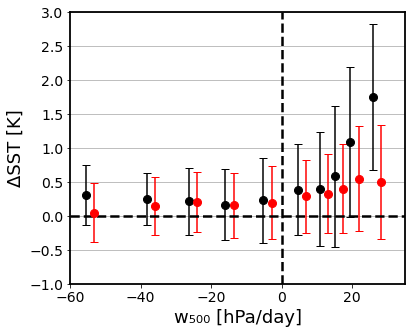

In [30]:
plot_composite_bins(df_sst23, df_sstcomp, var_label='ΔSST [K]', legend = False)
plt.show()

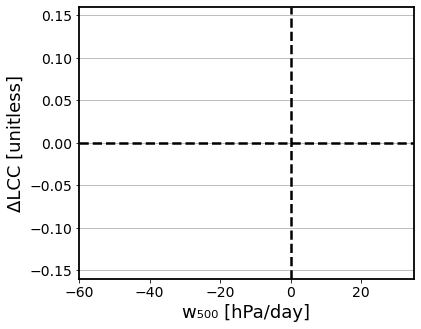

In [31]:
plot_composite_bins(df_LCC23, df_LCCcomp, var_label='ΔLCC [unitless]', legend = False)
plt.show()

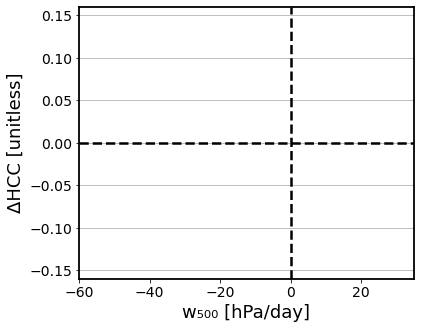

In [32]:
plot_composite_bins(df_HCC23, df_HCCcomp, var_label='ΔHCC [unitless]', legend = False)
plt.show()

Fig 2 j

In [34]:
dn_mean = xr.open_dataset('../preprocessed_data/fig2j.nc')


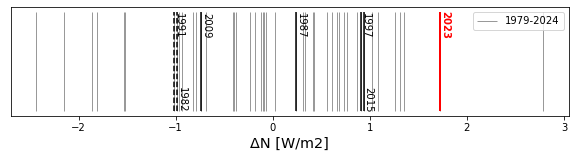

In [35]:

# Assuming dn_mean.n and dn_mean.year exist


composite_years = [1982, 1987, 1991, 1997,  2015, 2009]
dn_composite = dn_mean.where(dn_mean.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dn_mean.n, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dn_mean.sel(year = 1982).n, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1987).n, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 1991).n, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dn_mean.sel(year = 1997).n, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2009).n, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dn_mean.sel(year = 2015).n, ymin=0, ymax=1, color='black', linewidth=1.5)





for y in dn_composite.year.values: 
    x = dn_mean.sel(year = y).n
    if y in [1991, 1987, 1997, 2009]:
        ax.annotate(y, (x, 0.75), rotation = 270)
    else: 
        ax.annotate(y, (x, 0.), rotation = 270)
        

x = dn_mean.sel(year= 2023).n
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔN [W/m2]")
#ax.set_title("Barcode Plot of dn_mean.n")

plt.legend()
